# Step 1 : Import Libraries

In [9]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\20017\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# Step 2 : Load the dataset

In [17]:
import pandas as pd

df = pd.read_csv("combined_data.csv")

print("Shape:", df.shape)
print(df.head())
print("Columns:", df.columns)

Shape: (83448, 2)
   label                                               text
0      1  ounce feather bowl hummingbird opec moment ala...
1      1  wulvob get your medircations online qnb ikud v...
2      0   computer connection from cnn com wednesday es...
3      1  university degree obtain a prosperous future m...
4      0  thanks for all your answers guys i know i shou...
Columns: Index(['label', 'text'], dtype='object')


# Step2: split the data into X and y

In [19]:
X = df['text']
y = df['label']

print("X sample:\n", X.head())
print("y sample:\n", y.head())

print("X length:", len(X))
print("y length:", len(y))

X sample:
 0    ounce feather bowl hummingbird opec moment ala...
1    wulvob get your medircations online qnb ikud v...
2     computer connection from cnn com wednesday es...
3    university degree obtain a prosperous future m...
4    thanks for all your answers guys i know i shou...
Name: text, dtype: object
y sample:
 0    1
1    1
2    0
3    1
4    0
Name: label, dtype: int64
X length: 83448
y length: 83448


In [20]:
print(y.unique())

[1 0]


# Step 3:split the data train and test

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 66758
Test size: 16690


# Step 4 : Text preprocessing

In [22]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)   # remove special chars
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# Apply on train and test
X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)

print(X_train_clean.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\20017\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


9381     hi sent email last week need confirm everythin...
11566    taking requests http use perl org petdance jou...
40822    escapenumber escapenumber escapenumber tony ma...
35045    sunday escapenumber pril escapenumber escapenu...
38667    sally attached detail analysts energy operatio...
Name: text, dtype: object


# Step 4 : convert Text to vectorization

In [24]:
!pip install gensim

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   - -------------------------------------- 0.8/24.4 MB 2.8 MB/s eta 0:00:09
   -- ------------------------------------- 1.6/24.4 MB 3.2 MB/s eta 0:00:08
   --- ------------------------------------ 2.1/24.4 MB 3.0 MB/s eta 0:00:08
   ---- ----------------------------------- 2.9/24.4 MB 3.3 MB/s eta 0:00:07
   ---- ----------------------------------- 2.9/24.4 MB 3.3 MB/s eta 0:00:07
   ---- ----------------------------------- 2.9/24.4 MB 3.3 MB/s eta 0:00:07
   ---- ----------------------------------- 2.9/24.4 MB 3.3 MB/s eta 0:00:07
   ----- ---------------------------------- 3.1/24.4 MB 1.7 MB/s eta 0:00:13
   ----- ---------------------------------- 3.4/24.4 MB 1.7 MB/s eta 0:00:13
   ------ --------------------------------- 4.2/24.4 MB 1.8 MB/s eta 0:00:12
   -------- ------------------------------- 5.0/24.4 MB 2.0 MB/s eta 0:00:10
   --------- 

In [25]:
from gensim.models import Word2Vec
X_train_tokens = X_train_clean.apply(lambda x: x.split())
X_test_tokens = X_test_clean.apply(lambda x: x.split())

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=1,
    workers=4
)
import numpy as np

def sentence_vector(tokens, model):
    vectors = []
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
    
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    
    return np.mean(vectors, axis=0)

X_train_vec = np.array([sentence_vector(x, w2v_model) for x in X_train_tokens])
X_test_vec = np.array([sentence_vector(x, w2v_model) for x in X_test_tokens])

print(X_train_vec.shape)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


(66758, 100)


# Step 5 : Train Model

In [26]:
from sklearn.svm import LinearSVC

model = LinearSVC()
model.fit(X_train_vec, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,None


# Step 6 : predict on test Data

In [29]:
y_pred = model.predict(X_test_vec)

print(y_pred[:10])  # first 10 predictions

print("Actual:", list(y_test[:10]))
print("Predicted:", list(y_pred[:10]))

def predict_spam_w2v(text):
    text = clean_text(text)
    tokens = text.split()
    vec = sentence_vector(tokens, w2v_model).reshape(1, -1)
    pred = model.predict(vec)
    return "Spam" if pred[0] == 1 else "Not Spam"

print(predict_spam_w2v("Congratulations! You won a free lottery"))

print(predict_spam_w2v("Win money now!!!"))
print(predict_spam_w2v("Hi, how are you?"))

[0 1 1 1 0 0 1 1 0 0]
Actual: [0, 1, 1, 1, 0, 1, 1, 1, 0, 0]
Predicted: [np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
Spam
Spam
Not Spam


# Step 7 : Evalution Metrics

Accuracy: 0.9649490713001797
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      7938
           1       0.97      0.97      0.97      8752

    accuracy                           0.96     16690
   macro avg       0.96      0.96      0.96     16690
weighted avg       0.96      0.96      0.96     16690

[[7642  296]
 [ 289 8463]]


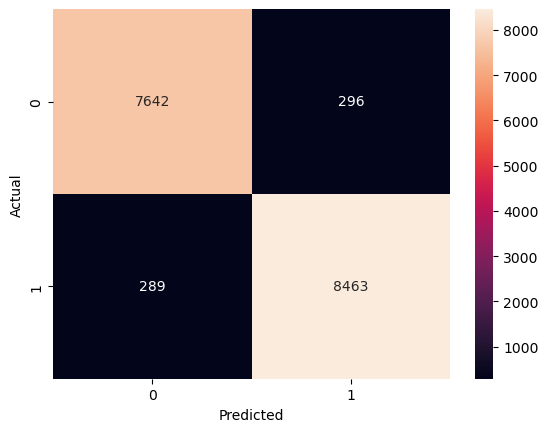

ROC-AUC: 0.9648449932820308


In [31]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

from sklearn.metrics import roc_auc_score

print("ROC-AUC:", roc_auc_score(y_test, y_pred))


# Step 8 : dump into pickle

In [33]:
import pickle

pickle.dump(model, open("svm_model.pkl", "wb"))

pickle.dump(w2v_model, open("w2v_vectorizer.pkl", "wb"))

model = pickle.load(open("svm_model.pkl", "rb"))
vectorizer = pickle.load(open("w2v_vectorizer.pkl", "rb"))

def predict_spam(text):
    text = clean_text(text)
    tokens = text.split()
    
    vec = sentence_vector(tokens, w2v_model).reshape(1, -1)
    
    pred = model.predict(vec)
    return "Spam" if pred[0] == 1 else "Not Spam"

print(predict_spam("Win a free iPhone now!!!"))


Spam
